# **Analisis Komparasi Algoritma Machine Learning untuk Deteksi Penipuan Transaksi Perbankan**

Nama: Muhammad Aksal Prasdion Aditya [F1G123023]

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Memuat Dataset
# Pastikan file FraudShield_Banking_Data.csv sudah di-upload ke Colab/Jupyter
df = pd.read_csv('FraudShield_Banking_Data.csv')

print("=== DATA UNDERSTANDING ===")
display(df.head())
print("\nInformasi Dataset:")
display(df.info())
print("\nStatistik Deskriptif:")
display(df.describe())

=== DATA UNDERSTANDING ===


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-n

None


Statistik Deskriptif:


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Merchant_ID,Distance_From_Home,Device_ID,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count
count,49997.000000,49990.000000,49991.000000,49993.000000,49998.000000,49991.000000,49991.000000,49991.000000,49995.000000,49991.000000,49996.000000,49989.000000,49997.000000
mean,550400.968898,54869.720744,4.999880,54951.375913,300.098564,552563.600088,20.993179,3.999460,12.520032,2.989098,5.016781,0.992798,0.500130
std,259677.602349,26052.824933,2.582025,25983.342481,172.848263,260186.451027,10.685467,2.002833,6.910709,1.413400,2.572913,0.816081,0.500005
min,100043.000000,10005.000000,1.000000,10001.000000,1.000000,100053.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,324445.000000,32259.250000,3.000000,32545.000000,150.000000,327643.500000,12.000000,2.000000,7.000000,2.000000,3.000000,0.000000,0.000000
50%,552115.000000,54720.500000,5.000000,54935.000000,301.000000,553372.000000,21.000000,4.000000,13.000000,3.000000,5.000000,1.000000,1.000000
75%,775942.000000,77542.000000,7.000000,77341.000000,449.000000,779903.500000,30.000000,6.000000,18.000000,4.000000,7.000000,2.000000,1.000000
max,999992.000000,99996.000000,9.000000,99996.000000,599.000000,999989.000000,39.000000,7.000000,24.000000,5.000000,9.000000,2.000000,1.000000


In [13]:
print("=== DATA PREPROCESSING ===")

# 2a. Menghapus kolom yang tidak relevan untuk pemodelan (ID dan data unik)
columns_to_drop = ['Transaction_ID', 'Customer_ID', 'Merchant_ID', 'Device_ID', 'IP_Address', 'Transaction_Time', 'Transaction_Date']
df_clean = df.drop(columns=columns_to_drop, errors='ignore')

# 2b. Mengatasi Missing Values (jika ada)
df_clean = df_clean.dropna() # Menghapus baris yang kosong

# 2c. Encoding Data Kategorikal
# Mengubah target label menjadi numerik (Normal = 0, Fraud = 1)
df_clean['Fraud_Label'] = df_clean['Fraud_Label'].map({'Normal': 0, 'Fraud': 1})

# Mengubah Yes/No menjadi 1/0
binary_cols = ['Is_International_Transaction', 'Is_New_Merchant', 'Unusual_Time_Transaction']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Menggunakan Label Encoder untuk kolom kategorikal lainnya
categorical_cols = ['Transaction_Type', 'Merchant_Category', 'Transaction_Location', 'Customer_Home_Location', 'Card_Type']
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("Data setelah preprocessing:")
display(df_clean.head())

# Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop('Fraud_Label', axis=1)
y = df_clean['Fraud_Label']

# 2d. Standarisasi/Normalisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

=== DATA PREPROCESSING ===
Data setelah preprocessing:


,Transaction_Amount (in Million),Transaction_Type,Merchant_Category,Transaction_Location,Customer_Home_Location,Distance_From_Home,Card_Type,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,6.0,2,0,9,3,466.0,0,30.0,4.0,17.0,2.0,4.0,1,1,0.0,0,1.0,0
1,9.0,0,0,9,3,215.0,0,4.0,4.0,9.0,5.0,8.0,1,1,1.0,0,1.0,0
2,3.0,2,2,2,0,216.0,1,38.0,5.0,18.0,5.0,8.0,1,0,0.0,1,1.0,0
3,1.0,1,4,7,2,408.0,1,22.0,6.0,18.0,5.0,1.0,0,1,2.0,1,1.0,0
4,1.0,1,2,9,1,209.0,1,10.0,3.0,18.0,4.0,3.0,0,1,1.0,0,1.0,0


=== EXPLORATORY DATA ANALYSIS (EDA) ===


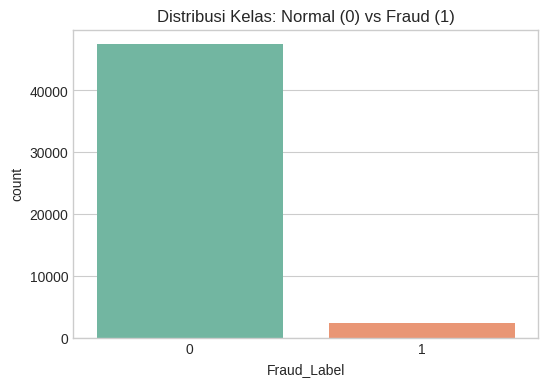

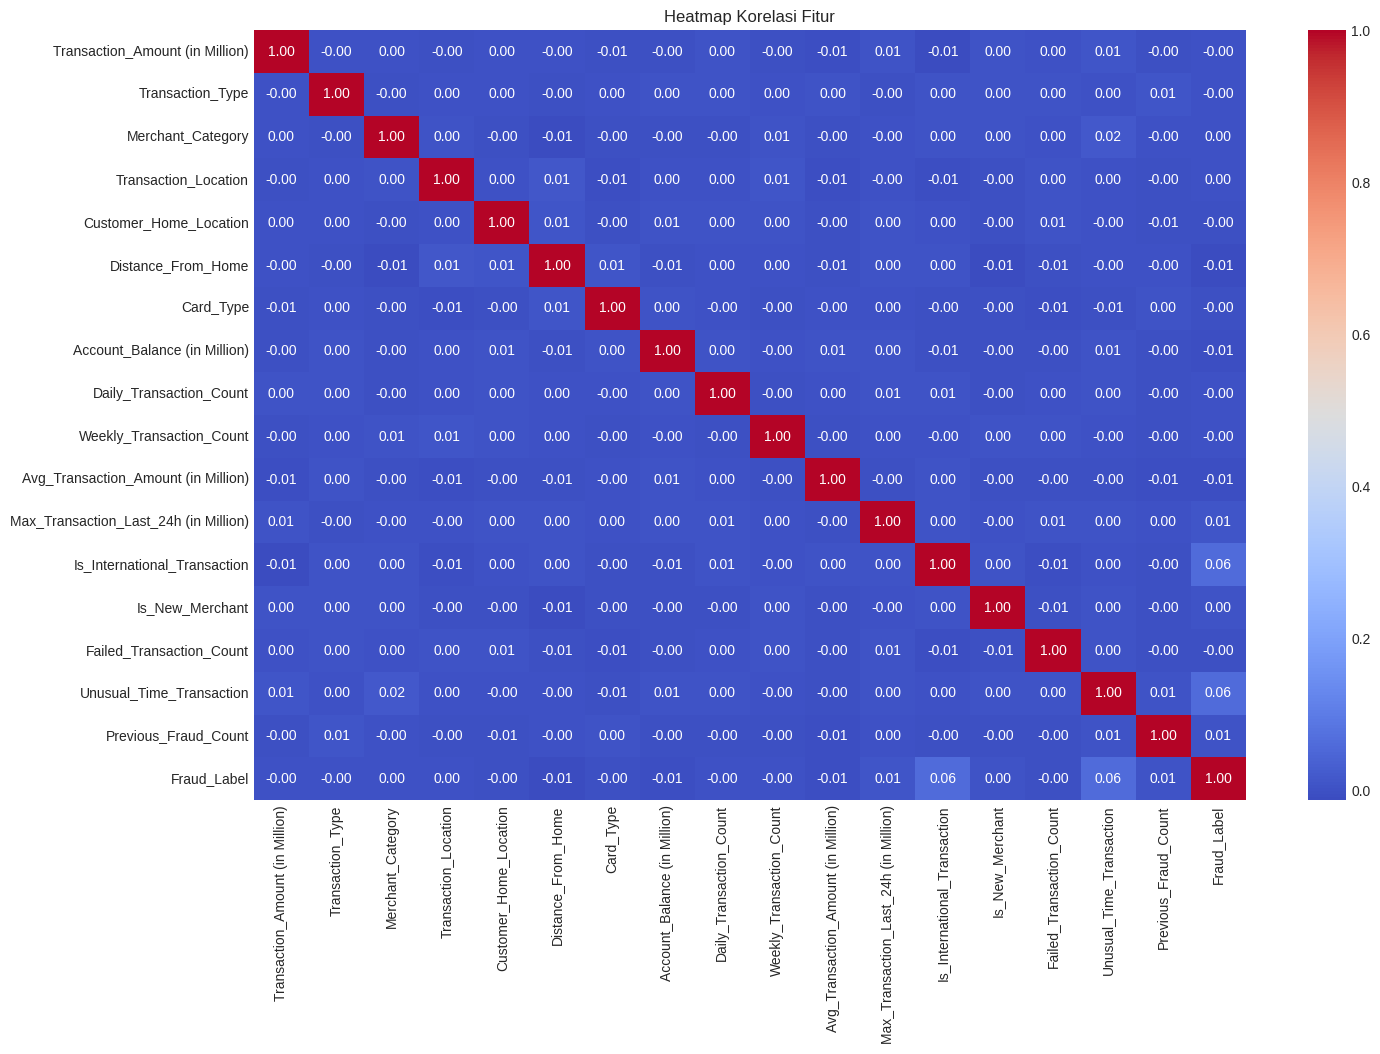

In [17]:
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")

# Distribusi Target
plt.figure(figsize=(6,4))
sns.countplot(x='Fraud_Label', data=df_clean, palette='Set2')
plt.title('Distribusi Kelas: Normal (0) vs Fraud (1)')
plt.show()

# Korelasi antar variabel
plt.figure(figsize=(16, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur')
plt.show()

=== ADDITIONAL EXPLORATORY DATA ANALYSIS ===


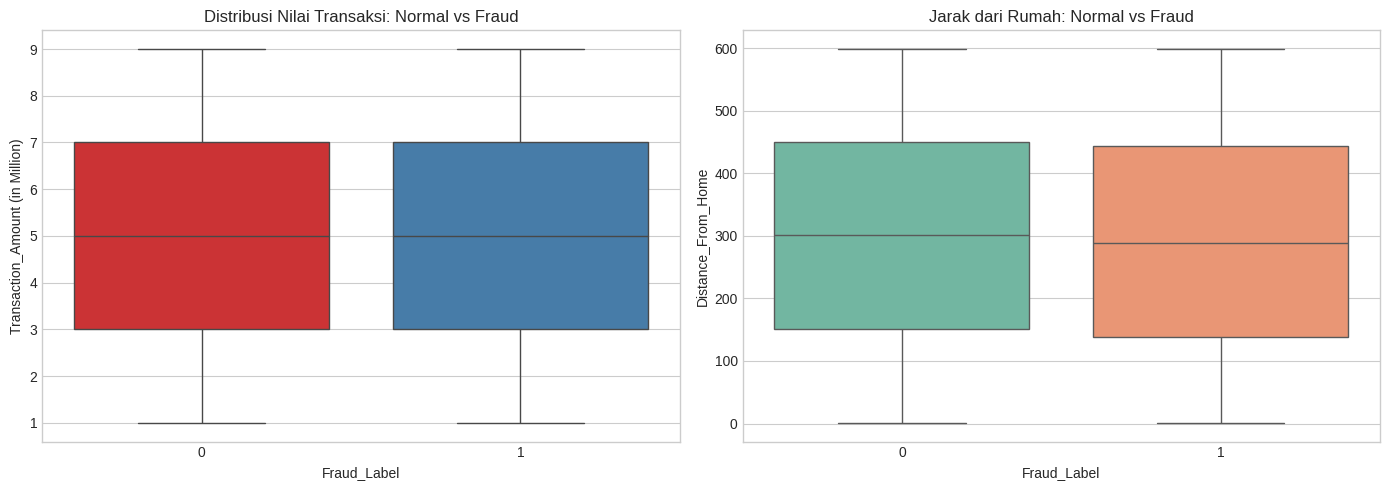

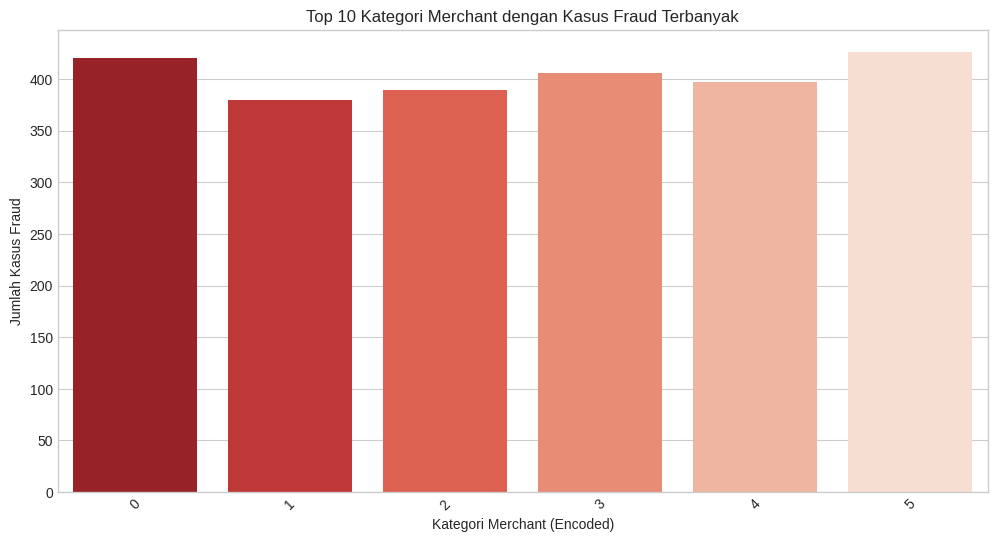

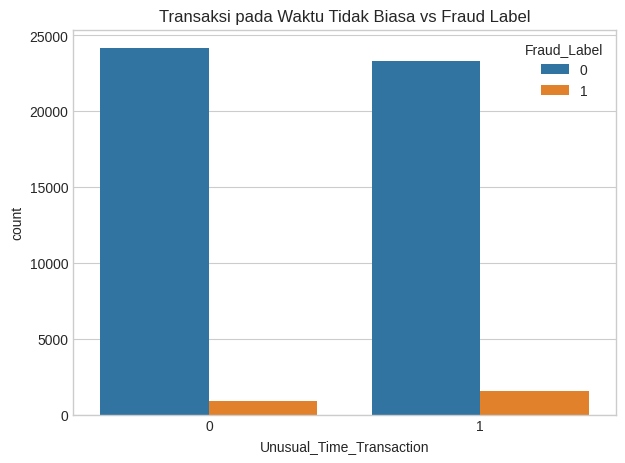

In [15]:
print("=== ADDITIONAL EXPLORATORY DATA ANALYSIS ===")

# 1. Visualisasi Fitur Numerik Penting
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Fraud_Label', y='Transaction_Amount (in Million)', data=df_clean, palette='Set1')
plt.title('Distribusi Nilai Transaksi: Normal vs Fraud')

plt.subplot(1, 2, 2)
sns.boxplot(x='Fraud_Label', y='Distance_From_Home', data=df_clean, palette='Set2')
plt.title('Jarak dari Rumah: Normal vs Fraud')

plt.tight_layout()
plt.show()

# 2. Perbandingan Kategori Merchant
plt.figure(figsize=(12, 6))
merchant_fraud = df_clean[df_clean['Fraud_Label'] == 1]['Merchant_Category'].value_counts().head(10)
sns.barplot(x=merchant_fraud.index, y=merchant_fraud.values, palette='Reds_r')
plt.title('Top 10 Kategori Merchant dengan Kasus Fraud Terbanyak')
plt.xlabel('Kategori Merchant (Encoded)')
plt.ylabel('Jumlah Kasus Fraud')
plt.xticks(rotation=45)
plt.show()

# 3. Fitur 'Unusual Time Transaction'
plt.figure(figsize=(7, 5))
sns.countplot(x='Unusual_Time_Transaction', hue='Fraud_Label', data=df_clean)
plt.title('Transaksi pada Waktu Tidak Biasa vs Fraud Label')
plt.show()

In [16]:
# Definisi Rasio Splitting
split_ratios = [(0.3, "70:30"), (0.2, "80:20"), (0.1, "90:10")]

# Definisi Algoritma & Parameter untuk Grid Search
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {'C': [0.1, 1, 10]}
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {'n_neighbors': [3, 5, 7]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {'n_estimators': [50, 100], 'max_depth': [10, None]}
    }
}

# Menyimpan hasil
results = []

for test_size, ratio_name in split_ratios:
    print(f"\n{'='*50}\nEVALUASI DENGAN RASIO SPLIT DATA {ratio_name}\n{'='*50}")

    # Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)

    for model_name, config in models.items():
        print(f"\n--- Melatih {model_name} ({ratio_name}) ---")

        # Hyperparameter Tuning menggunakan GridSearchCV
        grid = GridSearchCV(config["model"], config["params"], cv=3, scoring='accuracy')
        grid.fit(X_train, y_train)

        # Model Terbaik
        best_model = grid.best_estimator_
        print(f"Parameter Terbaik: {grid.best_params_}")

        # Prediksi & Evaluasi
        y_pred = best_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Menampilkan Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

        # Menyimpan ke dalam list untuk Dataframe Komparasi
        results.append({
            "Split Ratio": ratio_name,
            "Model": model_name,
            "Best Params": str(grid.best_params_),
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })


EVALUASI DENGAN RASIO SPLIT DATA 70:30

--- Melatih Logistic Regression (70:30) ---
Parameter Terbaik: {'C': 0.1}
Accuracy: 0.9516 | Precision: 0.0000 | Recall: 0.0000 | F1-Score: 0.0000

--- Melatih K-Nearest Neighbors (70:30) ---
Parameter Terbaik: {'n_neighbors': 7}
Accuracy: 0.9516 | Precision: 0.5000 | Recall: 0.0014 | F1-Score: 0.0028

--- Melatih Random Forest (70:30) ---
Parameter Terbaik: {'max_depth': 10, 'n_estimators': 50}
Accuracy: 0.9516 | Precision: 0.0000 | Recall: 0.0000 | F1-Score: 0.0000

EVALUASI DENGAN RASIO SPLIT DATA 80:20

--- Melatih Logistic Regression (80:20) ---
Parameter Terbaik: {'C': 0.1}
Accuracy: 0.9515 | Precision: 0.0000 | Recall: 0.0000 | F1-Score: 0.0000

--- Melatih K-Nearest Neighbors (80:20) ---
Parameter Terbaik: {'n_neighbors': 7}
Accuracy: 0.9513 | Precision: 0.0000 | Recall: 0.0000 | F1-Score: 0.0000

--- Melatih Random Forest (80:20) ---
Parameter Terbaik: {'max_depth': 10, 'n_estimators': 50}
Accuracy: 0.9515 | Precision: 0.0000 | Recall: 

=== MODEL COMPARISON ===


,Split Ratio,Model,Best Params,Accuracy,Precision,Recall,F1-Score
0,70:30,Logistic Regression,{'C': 0.1},0.951570,0.0,0.000000,0.000000
1,70:30,K-Nearest Neighbors,{'n_neighbors': 7},0.951570,0.5,0.001379,0.002751
2,70:30,Random Forest,"{'max_depth': 10, 'n_estimators': 50}",0.951570,0.0,0.000000,0.000000
3,80:20,Logistic Regression,{'C': 0.1},0.951503,0.0,0.000000,0.000000
5,80:20,Random Forest,"{'max_depth': 10, 'n_estimators': 50}",0.951503,0.0,0.000000,0.000000
8,90:10,Random Forest,"{'max_depth': 10, 'n_estimators': 50}",0.951503,0.0,0.000000,0.000000
6,90:10,Logistic Regression,{'C': 0.1},0.951503,0.0,0.000000,0.000000
4,80:20,K-Nearest Neighbors,{'n_neighbors': 7},0.951303,0.0,0.000000,0.000000
7,90:10,K-Nearest Neighbors,{'n_neighbors': 7},0.951303,0.0,0.000000,0.000000


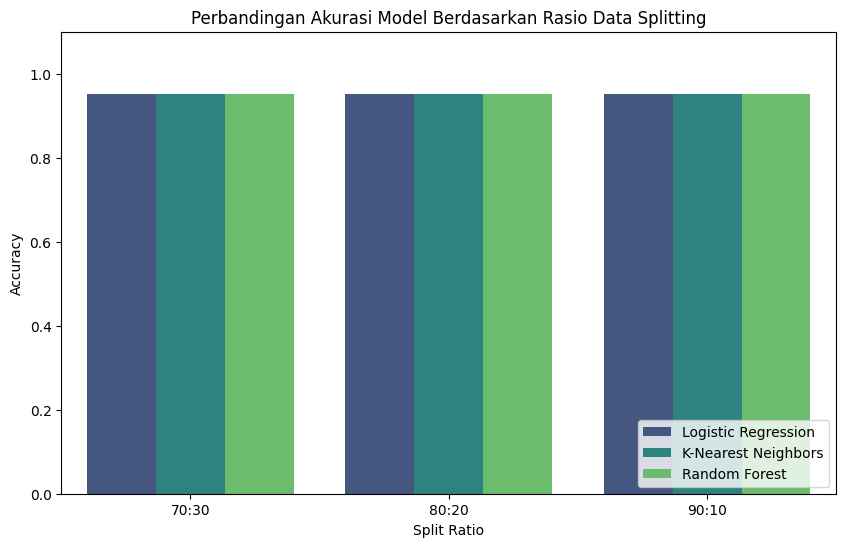

In [ ]:
print("=== MODEL COMPARISON ===")
df_results = pd.DataFrame(results)

# Menampilkan Tabel Komparasi
display(df_results.sort_values(by="Accuracy", ascending=False))

# Visualisasi Komparasi Akurasi
plt.figure(figsize=(10,6))
sns.barplot(x="Split Ratio", y="Accuracy", hue="Model", data=df_results, palette="viridis")
plt.title('Perbandingan Akurasi Model Berdasarkan Rasio Data Splitting')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()